In [8]:
#Instalar librerias
!pip install dtreeviz
!pip install catboost
!pip install shap
!pip install xgboost
!pip install optbinning
!pip install lightgbm

In [9]:
#Importo librerias necesarias para el proceso de EDA (Esploratory Data Analysis)
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import folium
import numpy as np
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go


#Importo librerias necesarias para el proceso de Feature engineering y evaluación de modelos
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, r2_score, mean_squared_error
from sklearn.metrics import roc_curve, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import fetch_california_housing

#Importo librerias necesarias para ML
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from xgboost import XGBClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
import shap
from sklearn.tree import export_graphviz
import graphviz
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter(action='ignore', category=FutureWarning)



# Descripción del Dataset: California Housing

El dataset California Housing fue construido a partir del censo de Estados Unidos de 1990 y contiene información sobre distintos grupos censales del estado de California. Cada observación representa una zona geográfica con características demográficas, económicas y estructurales, y el objetivo es predecir el valor medio de las viviendas en esa zona.

## Objetivo del análisis

El propósito principal de este dataset es modelar el valor medio de las viviendas (`MedHouseVal`) en función de variables como el ingreso medio, la edad promedio de las casas, la densidad poblacional y la ubicación geográfica.

## Estructura del dataset

El conjunto de datos contiene aproximadamente 20,640 observaciones, 8 variables predictoras numéricas y 1 variable objetivo continua.

## Variables incluidas

- `MedInc`: Ingreso medio por hogar en el grupo censal (en decenas de miles de dólares)
- `HouseAge`: Edad promedio de las viviendas en años
- `AveRooms`: Promedio de habitaciones por hogar
- `AveBedrms`: Promedio de dormitorios por hogar
- `Population`: Población total del grupo censal
- `AveOccup`: Promedio de ocupantes por hogar
- `Latitude`: Latitud geográfica del grupo censal
- `Longitude`: Longitud geográfica del grupo censal

La variable objetivo es:

- `MedHouseVal`: Valor medio de las viviendas en cientos de miles de dólares (por ejemplo, 2.5 representa $250,000)



In [10]:

# Cargar dataset
data = fetch_california_housing()
X, y = data.data, data.target

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


Random forest regressor

In [11]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
rf.score(X_test, y_test) # estadistico R2


0.8087475407581369

Boosting regressors

In [12]:
gb = GradientBoostingRegressor()
xgb = XGBRegressor()
lgbm = LGBMRegressor()
cat = CatBoostRegressor(verbose=0)

for model in [gb, xgb, lgbm, cat]:
    model.fit(X_train, y_train)
    print(f"{model.__class__.__name__}: {model.score(X_test, y_test):.4f}")


GradientBoostingRegressor: 0.7756
XGBRegressor: 0.8301
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001311 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 8
[LightGBM] [Info] Start training from score 2.071947
LGBMRegressor: 0.8369
CatBoostRegressor: 0.8492


Bagging regresor

In [13]:
bag = BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=50)
bag.fit(X_train, y_train)
bag.score(X_test, y_test)


0.8051728828754089

Comparacion final

In [14]:
from sklearn.metrics import mean_squared_error

models = {
    'Random Forest': rf,
    'Bagging': bag,
    'Gradient Boosting': gb,
    'XGBoost': xgb,
    'LightGBM': lgbm,
    'CatBoost': cat
}

results = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred)
    results[name] = rmse

import pandas as pd
pd.Series(results).sort_values()


,0
CatBoost,0.197608
LightGBM,0.213682
XGBoost,0.222590
Random Forest,0.250619
Bagging,0.255303
Gradient Boosting,0.294080


In [15]:
models = {
    'Random Forest': rf,
    'Bagging': bag,
    'Gradient Boosting': gb,
    'XGBoost': xgb,
    'LightGBM': lgbm,
    'CatBoost': cat
}

r2_results = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    r2_results[name] = r2

# Mostrar resultados ordenados de mayor a menor R²
pd.Series(r2_results).sort_values(ascending=False)


,0
CatBoost,0.849201
LightGBM,0.836935
XGBoost,0.830137
Random Forest,0.808748
Bagging,0.805173
Gradient Boosting,0.775581


In [16]:
import matplotlib.pyplot as plt
import numpy as np


def plot_predictions(model, X_test, y_test, title=None):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)

    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, y_pred, alpha=0.4, edgecolor='k')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel("Valor real")
    plt.ylabel("Predicción")
    plt.title(title or f"{model.__class__.__name__} (R² = {r2:.2f})")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


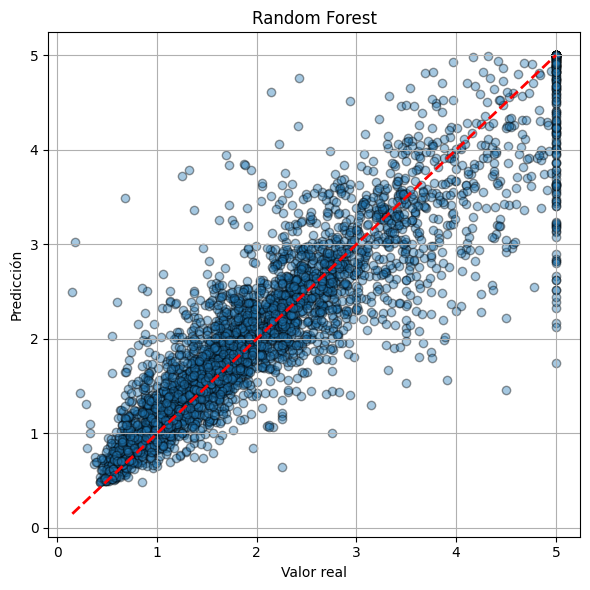

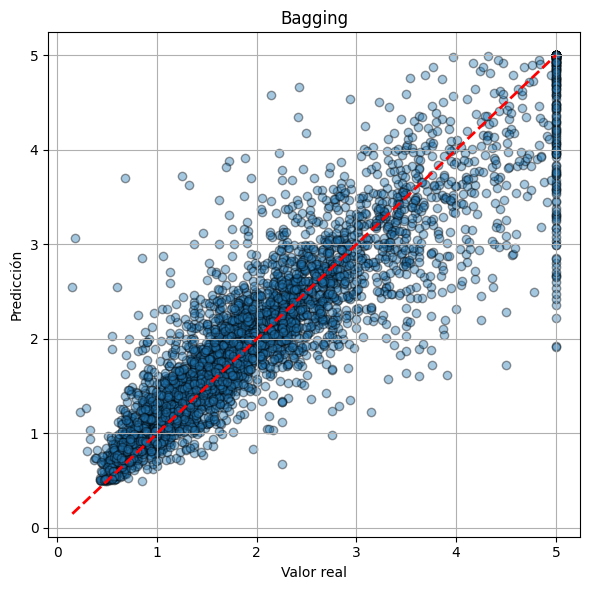

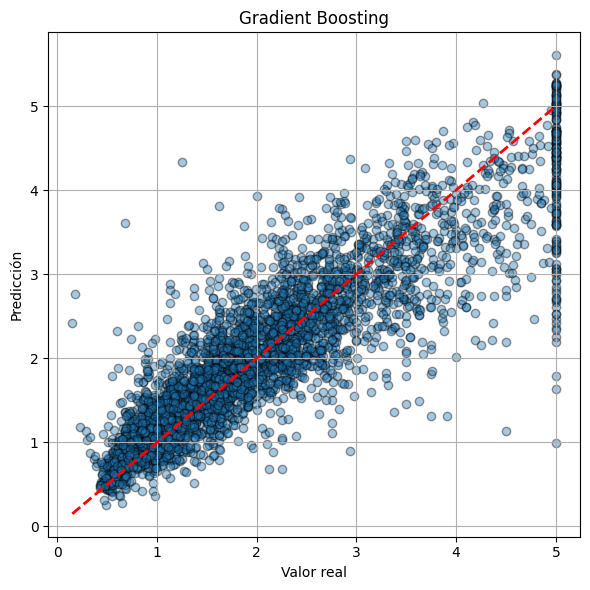

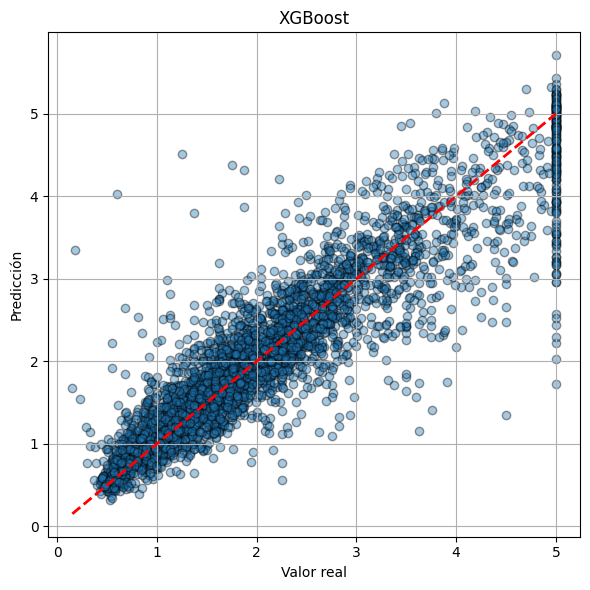

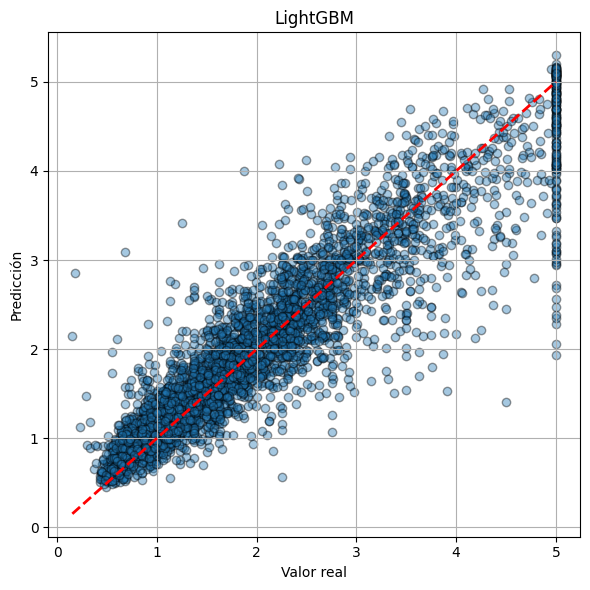

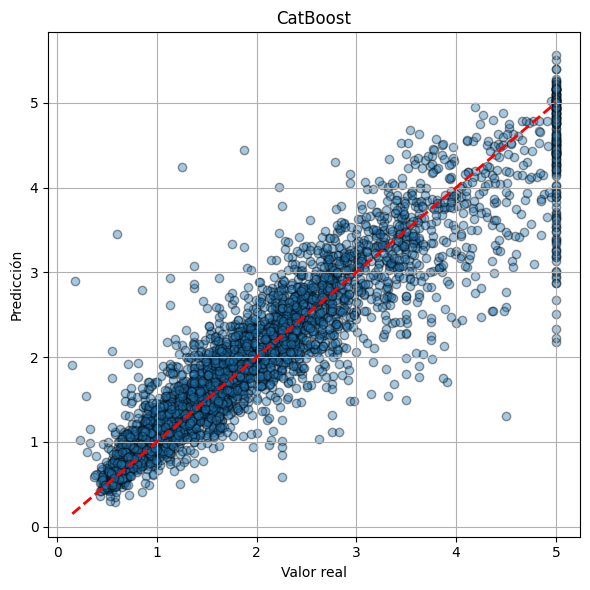

In [17]:
plot_predictions(rf, X_test, y_test, "Random Forest")
plot_predictions(bag, X_test, y_test, "Bagging")
plot_predictions(gb, X_test, y_test, "Gradient Boosting")
plot_predictions(xgb, X_test, y_test, "XGBoost")
plot_predictions(lgbm, X_test, y_test, "LightGBM")
plot_predictions(cat, X_test, y_test, "CatBoost")


In [19]:
# Instanciar y entrenar el modelo
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predicciones
y_pred_lr = lr.predict(X_test)

# Métricas
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr)

print(f"Regresión Lineal - R²: {r2_lr:.4f}, RMSE: {rmse_lr:.2f}")


Regresión Lineal - R²: 0.5758, RMSE: 0.56


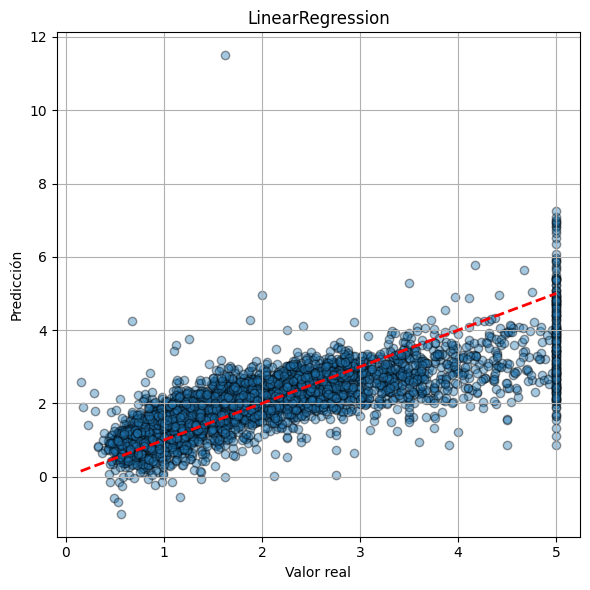

In [20]:
plot_predictions(lr, X_test, y_test, "LinearRegression")